# Optuna Plots Examples

This notebook demonstrates the usage of the OptunaPlots class methods for hyperparameter optimization visualization. The OptunaPlots class provides comprehensive tools for analyzing Optuna studies including optimization history, parameter importance, and parameter relationships.

In [1]:
import numpy as np
import optuna
from sklearn.datasets import make_classification, make_regression, load_wine, load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from kvbiii_plots.ml.optuna_plots import OptunaPlots

/home/kvbiii/Desktop/KubiK/Programming/Python/Paczki/kvbiii-plots/kvbiii-plots_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
optuna_plots = OptunaPlots()

np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("OptunaPlots initialized successfully!")
print("Available methods:")
methods = [method for method in dir(optuna_plots) if method.startswith("plot_")]
for method in methods:
    print(f"  - {method}")

OptunaPlots initialized successfully!
Available methods:
  - plot_optuna_optimization_history
  - plot_optuna_param_importance


## Prepare Datasets and Objective Functions

We'll create different optimization scenarios to demonstrate various OptunaPlots capabilities:
1. Classification with Random Forest
2. Regression with multiple algorithms
3. Neural Network optimization
4. Support Vector Machine tuning

In [3]:
print("Preparing datasets...")

X_class_synthetic, y_class_synthetic = make_classification(
    n_samples=1000, n_features=20, n_informative=10, n_redundant=5, n_classes=3, random_state=42
)

wine_data = load_wine()
X_wine, y_wine = wine_data.data, wine_data.target

X_reg_synthetic, y_reg_synthetic = make_regression(
    n_samples=1000, n_features=15, noise=0.1, random_state=42
)

diabetes_data = load_diabetes()
X_diabetes, y_diabetes = diabetes_data.data, diabetes_data.target

print(f"Synthetic classification: {X_class_synthetic.shape}")
print(f"Wine dataset: {X_wine.shape}")
print(f"Synthetic regression: {X_reg_synthetic.shape}")
print(f"Diabetes dataset: {X_diabetes.shape}")

Preparing datasets...
Synthetic classification: (1000, 20)
Wine dataset: (178, 13)
Synthetic regression: (1000, 15)
Diabetes dataset: (442, 10)


In [4]:


def rf_classification_objective(trial):
    """Random Forest classification optimization."""
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
    )

    scores = cross_val_score(model, X_wine, y_wine, cv=5, scoring="accuracy")
    return scores.mean()


def multi_algorithm_regression_objective(trial):
    """Multi-algorithm regression optimization."""
    algorithm = trial.suggest_categorical("algorithm", ["rf", "ridge", "svr"])

    if algorithm == "rf":
        n_estimators = trial.suggest_int("rf_n_estimators", 10, 100)
        max_depth = trial.suggest_int("rf_max_depth", 3, 15)
        model = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth, random_state=42
        )
    elif algorithm == "ridge":
        alpha = trial.suggest_float("ridge_alpha", 0.01, 100.0, log=True)
        model = Ridge(alpha=alpha, random_state=42)
    else:       
        C = trial.suggest_float("svr_C", 0.1, 100.0, log=True)
        gamma = trial.suggest_float("svr_gamma", 0.001, 1.0, log=True)
        model = SVR(C=C, gamma=gamma)

    scores = cross_val_score(model, X_diabetes, y_diabetes, cv=3, scoring="neg_mean_squared_error")
    return scores.mean()


print("Objective functions defined successfully!")

Objective functions defined successfully!


## Create Optuna Studies

We'll create different studies to demonstrate various optimization scenarios and plotting capabilities.

In [5]:
print("Creating Optuna studies...")

print("Running Random Forest classification optimization...")
study_rf_class = optuna.create_study(direction="maximize", study_name="rf_classification")
study_rf_class.optimize(rf_classification_objective, n_trials=50)
print(f"Best accuracy: {study_rf_class.best_value:.4f}")

print("\nRunning multi-algorithm regression optimization...")
study_multi_reg = optuna.create_study(direction="maximize", study_name="multi_regression")
study_multi_reg.optimize(multi_algorithm_regression_objective, n_trials=75)
print(f"Best score: {study_multi_reg.best_value:.4f}")

print("\nAll studies completed!")

Creating Optuna studies...
Running Random Forest classification optimization...
Best accuracy: 0.9832

Running multi-algorithm regression optimization...
Best score: -3022.6437

All studies completed!


## 1. plot_optuna_optimization_history() - Optimization Progress Visualization

This plot shows the progression of trials over time and tracks the best score achieved so far. It's essential for understanding convergence behavior and optimization progress.

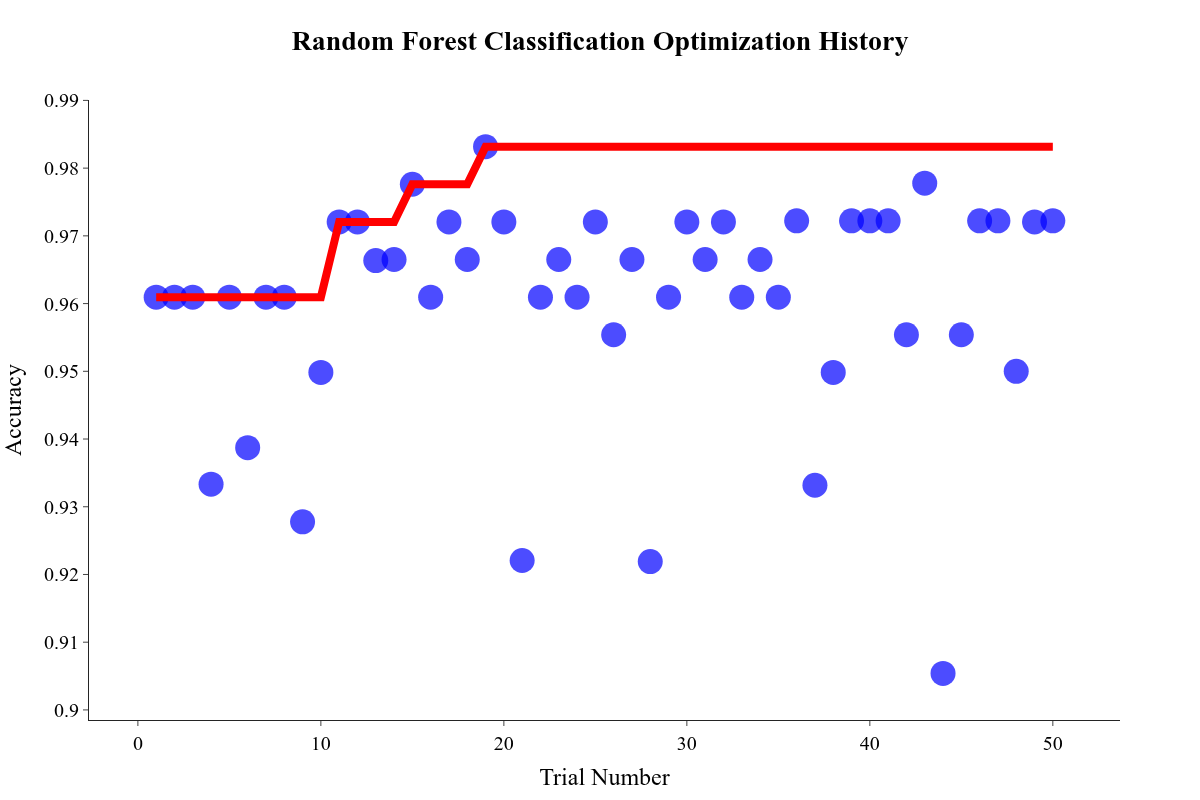

In [6]:
optuna_plots.plot_optuna_optimization_history(
    study=study_rf_class,
    plot_title="Random Forest Classification Optimization History",
    direction="maximize",
    yaxis_title="Accuracy",
)

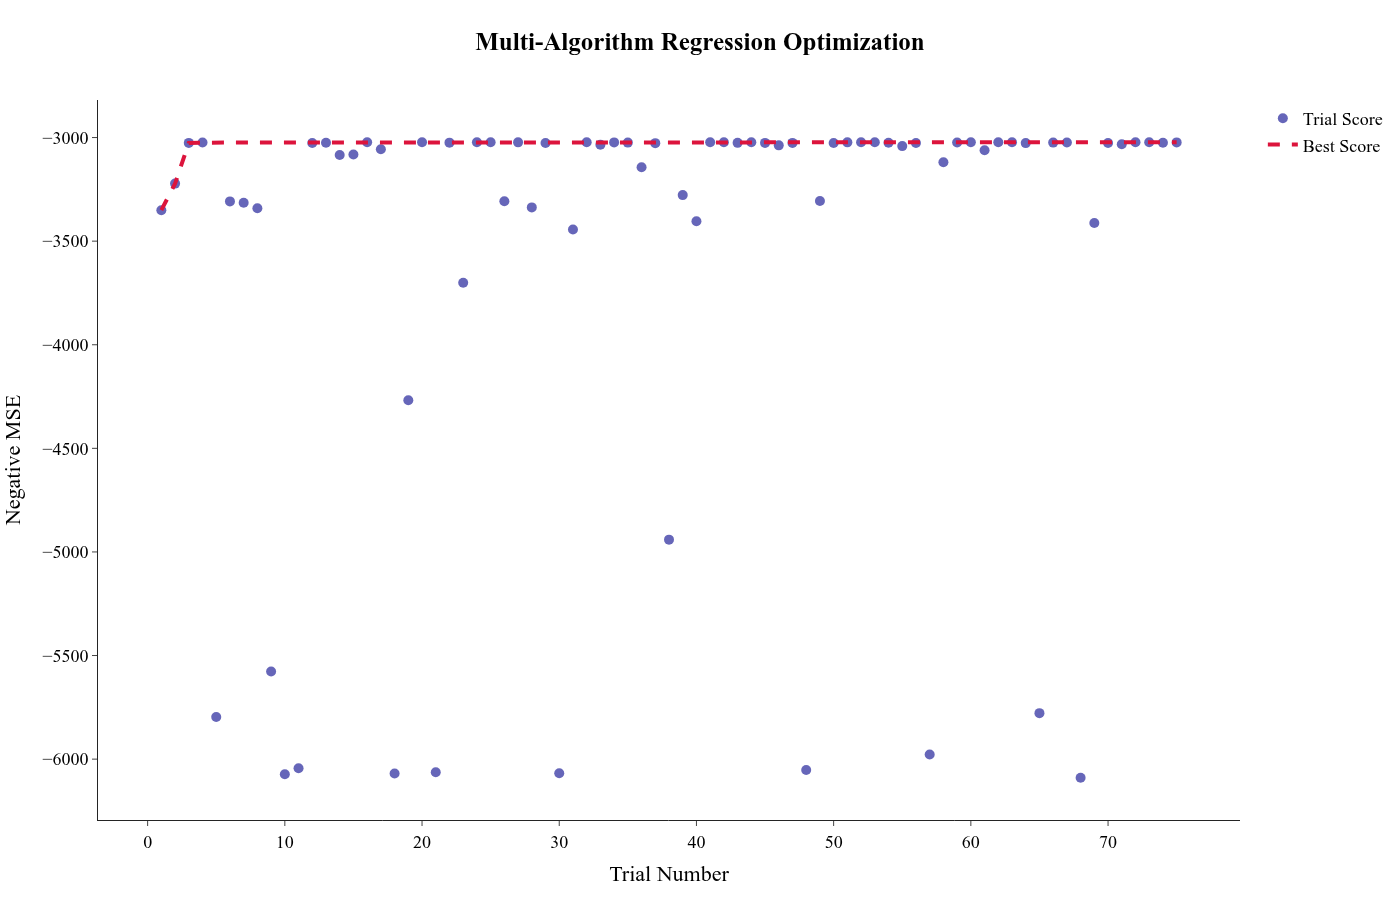

In [7]:
optuna_plots.plot_optuna_optimization_history(
    study=study_multi_reg,
    plot_title="Multi-Algorithm Regression Optimization",
    width=1400,
    height=900,
    xaxis_title="Trial Number",
    yaxis_title="Negative MSE",
    direction="maximize",
    marker_size=10,
    marker_color="darkblue",
    marker_opacity=0.6,
    line_color="crimson",
    line_width=4,
    line_dash="dash",
    show_trial_legend=True,
    show_best_legend=True,
    font_size=18,
)

## 2. plot_optuna_param_importance() - Parameter Importance Analysis

This plot shows which hyperparameters have the most impact on the objective function. It helps identify the most critical parameters for optimization.

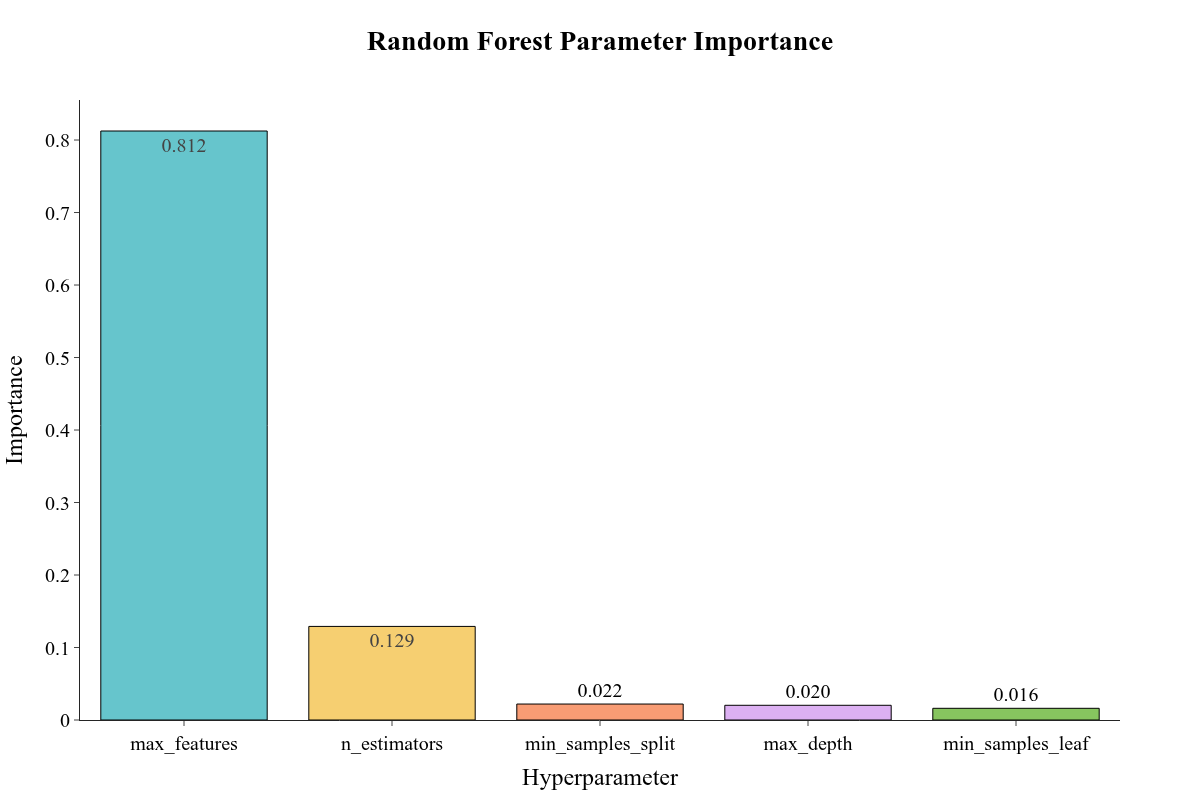

In [8]:
optuna_plots.plot_optuna_param_importance(
    study=study_rf_class, plot_title="Random Forest Parameter Importance"
)

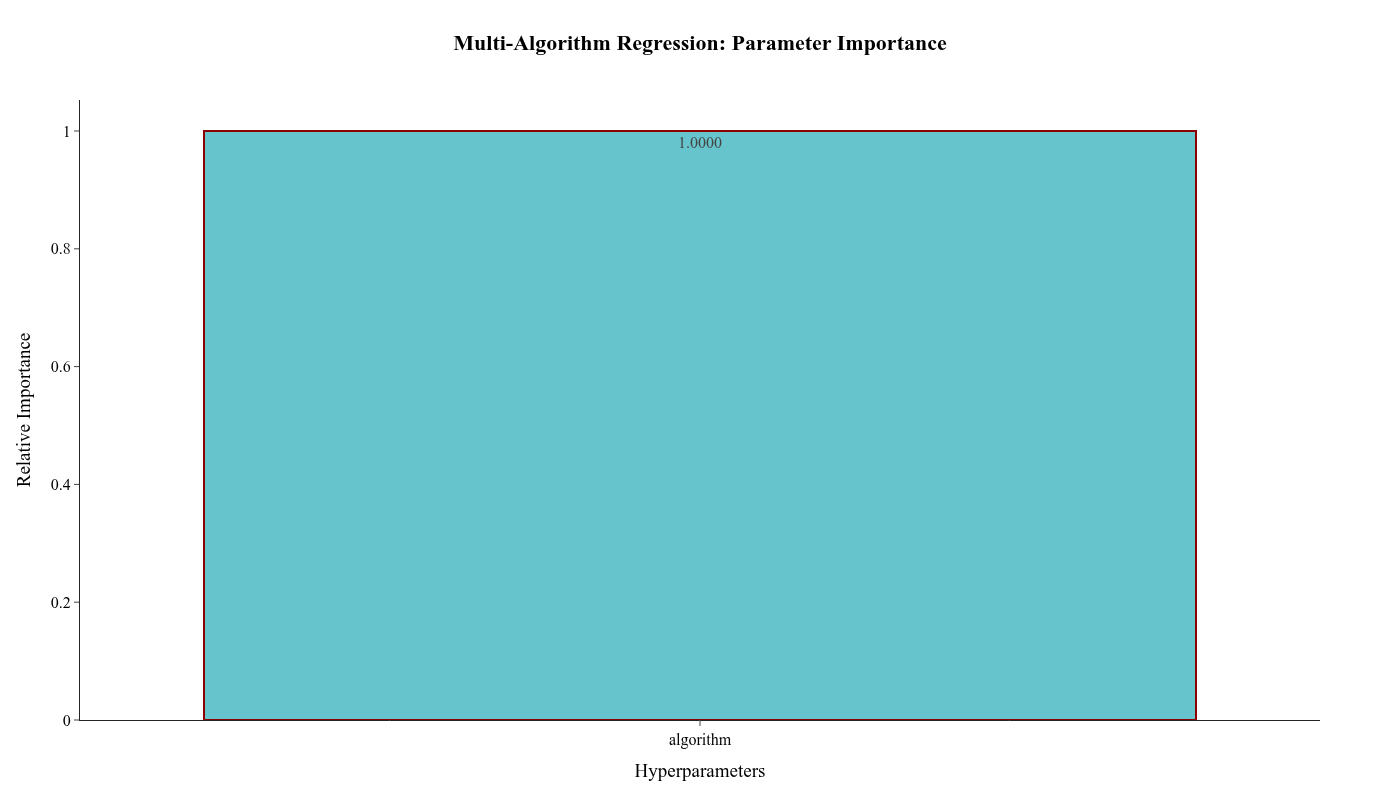

In [9]:
optuna_plots.plot_optuna_param_importance(
    study=study_multi_reg,
    plot_title="Multi-Algorithm Regression: Parameter Importance",
    width=1400,
    height=800,
    xaxis_title="Hyperparameters",
    yaxis_title="Relative Importance",
    use_qualitative_colors=True,
    show_values=True,
    value_precision=4,
    bar_line_color="darkred",
    bar_line_width=2,
    font_size=16,
    sort_descending=True,
)